In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('TSLA.csv')
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,19.000000,25.000000,17.540001,23.889999,23.889999,18766300
1,2010-06-30,25.790001,30.420000,23.299999,23.830000,23.830000,17187100
2,2010-07-01,25.000000,25.920000,20.270000,21.959999,21.959999,8218800
3,2010-07-02,23.000000,23.100000,18.709999,19.200001,19.200001,5139800
4,2010-07-06,20.000000,20.000000,15.830000,16.110001,16.110001,6866900
...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2416 entries, 0 to 2415
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2416 non-null   str    
 1   Open       2416 non-null   float64
 2   High       2416 non-null   float64
 3   Low        2416 non-null   float64
 4   Close      2416 non-null   float64
 5   Adj Close  2416 non-null   float64
 6   Volume     2416 non-null   int64  
dtypes: float64(5), int64(1), str(1)
memory usage: 132.3 KB


In [18]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,2416.000000,2416.000000,2416.000000,2416.000000,2416.000000,2.416000e+03
mean,186.271147,189.578224,182.916639,186.403651,186.403651,5.572722e+06
std,118.740163,120.892329,116.857591,119.136020,119.136020,4.987809e+06
min,16.139999,16.629999,14.980000,15.800000,15.800000,1.185000e+05
25%,34.342498,34.897501,33.587501,34.400002,34.400002,1.899275e+06
50%,213.035004,216.745002,208.870002,212.960007,212.960007,4.578400e+06
75%,266.450012,270.927513,262.102501,266.774994,266.774994,7.361150e+06
max,673.690002,786.140015,673.520020,780.000000,780.000000,4.706500e+07


In [20]:
df.duplicated().sum()

np.int64(0)

In [39]:
df["HL Range"]= (df["High"] - df["Low"])
df["SMA-5"]=df["Close"].rolling(5).mean()
df["SMA-10"]=df["Close"].rolling(10).mean()
df["SMA-20"]=df["Close"].rolling(20).mean()
df["SMA-50"]=df["Close"].rolling(50).mean()

In [45]:
df["Volume-5"]=df["Volume"].rolling(5).mean()
df["Volume-10"]=df["Volume"].rolling(10).mean()
df["Volume-30"]=df["Volume"].rolling(30).mean()

In [47]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month

df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

In [50]:
df["day_of_week"] = df["Date"].dt.dayofweek

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)

In [86]:
df["Returns"] = df["Close"].pct_change()
df["Volatility_5"] = df["Returns"].rolling(5).std()
df["Volatility_10"] = df["Returns"].rolling(10).std()


In [98]:
corr_with_target = df.corr()["Adj Close"].sort_values(ascending=False)
print(corr_with_target)

Close            1.000000
Adj Close        1.000000
High             0.999623
Low              0.999419
Open             0.998830
SMA-5            0.997792
SMA-10           0.994999
SMA-20           0.989244
SMA-50           0.972845
Date             0.884480
Year             0.880079
HL Range         0.693370
Volume-30        0.657433
Volume-10        0.615145
Volume-5         0.576302
Volume           0.499237
Returns          0.030037
dow_cos          0.003673
Month            0.003568
Month_cos        0.000476
dow_sin         -0.003328
day_of_week     -0.003342
Month_sin       -0.038187
Volatility_5    -0.126329
Volatility_10   -0.171651
Name: Adj Close, dtype: float64


In [87]:
df.dropna(inplace=True)
df

,Date,Open,High,Low,Close,Adj Close,Volume,HL Range,SMA-5,SMA-10,...,Year,Month,Month_sin,Month_cos,day_of_week,dow_sin,dow_cos,Returns,Volatility_5,Volatility_10
59,2010-09-22,20.870001,20.950001,19.799999,19.870001,19.870001,962900,1.150002,20.574000,20.757000,...,2010,9,-1.000000,-1.836970e-16,2,0.974928,-0.222521,-0.043332,0.036214,0.034111
60,2010-09-23,19.889999,20.139999,19.500000,19.559999,19.559999,668100,0.639999,20.298000,20.642000,...,2010,9,-1.000000,-1.836970e-16,3,0.433884,-0.900969,-0.015602,0.032724,0.034269
61,2010-09-24,19.950001,20.190001,19.650000,20.100000,20.100000,578900,0.540001,20.272000,20.635000,...,2010,9,-1.000000,-1.836970e-16,4,-0.433884,-0.900969,0.027607,0.034470,0.034831
62,2010-09-27,20.400000,20.809999,20.049999,20.530001,20.530001,418600,0.760000,20.166000,20.616000,...,2010,9,-1.000000,-1.836970e-16,0,0.000000,1.000000,0.021393,0.029232,0.034370
63,2010-09-28,21.040001,21.490000,20.760000,21.400000,21.400000,1214500,0.730000,20.292000,20.644000,...,2010,9,-1.000000,-1.836970e-16,1,0.781831,0.623490,0.042377,0.035093,0.036544
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2411,2020-01-28,568.489990,576.809998,558.080017,566.900024,566.900024,11788500,18.729981,566.300012,545.911005,...,2020,1,0.500000,8.660254e-01,1,0.781831,0.623490,0.015913,0.022303,0.031282
2412,2020-01-29,575.690002,589.799988,567.429993,580.989990,580.989990,17801500,22.369995,568.586011,550.218005,...,2020,1,0.500000,8.660254e-01,2,0.974928,-0.222521,0.024854,0.016733,0.031280
2413,2020-01-30,632.419983,650.880005,618.000000,640.809998,640.809998,29005700,32.880005,582.308008,562.449005,...,2020,1,0.500000,8.660254e-01,3,0.433884,-0.900969,0.102962,0.047332,0.039299
2414,2020-01-31,640.000000,653.000000,632.520020,650.570007,650.570007,15719300,20.479980,599.458008,576.157007,...,2020,1,0.500000,8.660254e-01,4,-0.433884,-0.900969,0.015231,0.043393,0.037826


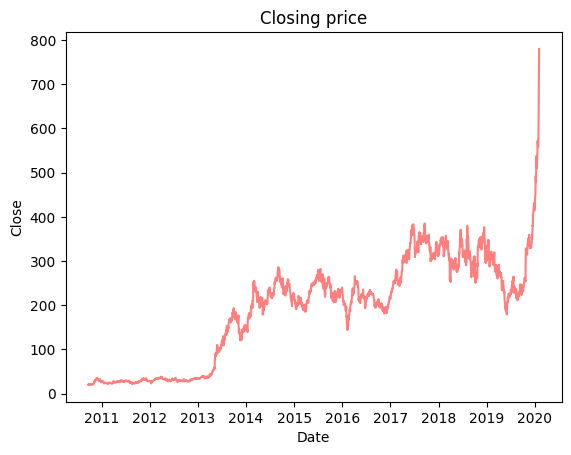

In [133]:
df["Date"] = pd.to_datetime(df["Date"])
plt.plot(df["Date"],df["Close"],color="red",alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Closing price")
plt.show()

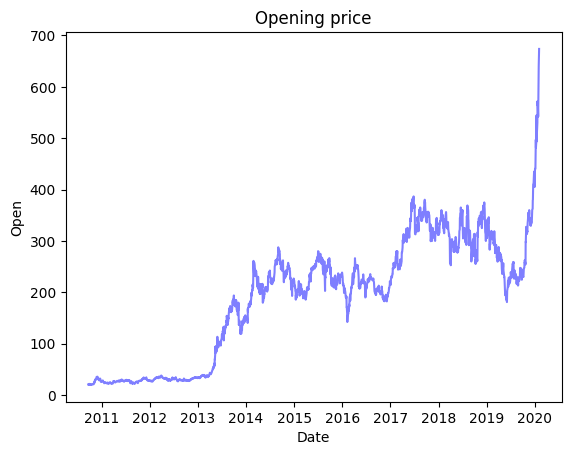

In [134]:
plt.plot(df["Date"],df["Open"],color="blue",alpha=0.5)
plt.xlabel("Date")
plt.ylabel("Open")
plt.title("Opening price")
plt.show()

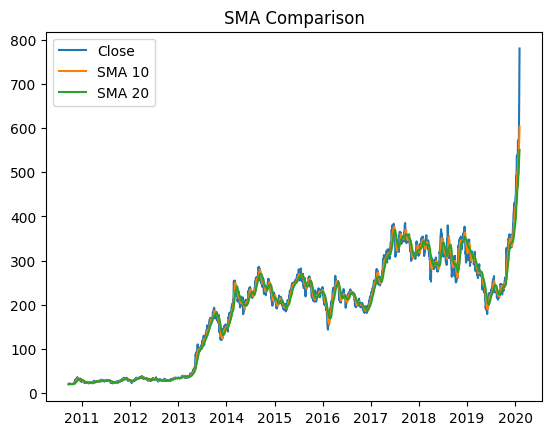

In [135]:
plt.plot(df["Date"], df["Close"], label="Close")
plt.plot(df["Date"], df["SMA-10"], label="SMA 10")
plt.plot(df["Date"], df["SMA-20"], label="SMA 20")
plt.title("SMA Comparison")
plt.legend()
plt.show()

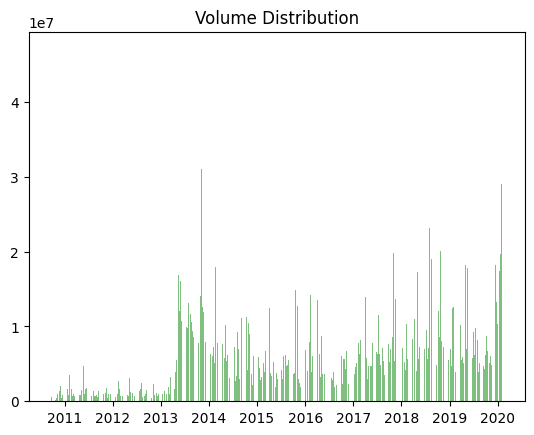

In [136]:
plt.bar(df["Date"], df["Volume"], alpha=0.5,color="green")
plt.title("Volume Distribution")
plt.show()

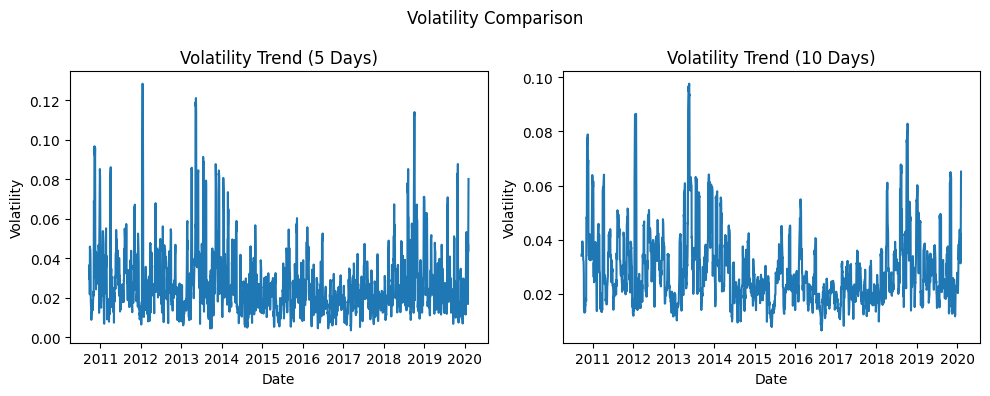

In [129]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1
axs[0].plot(df["Date"], df["Volatility_5"])
axs[0].set_title("Volatility Trend (5 Days)")
axs[0].set_xlabel("Date")
axs[0].set_ylabel("Volatility")

# Plot 2
axs[1].plot(df["Date"], df["Volatility_10"])
axs[1].set_title("Volatility Trend (10 Days)")
axs[1].set_xlabel("Date")
axs[1].set_ylabel("Volatility")

# Overall title
fig.suptitle("Volatility Comparison")

plt.tight_layout()
plt.show()

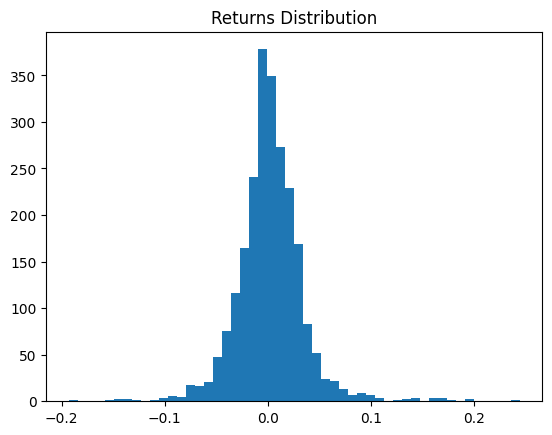

In [131]:
plt.hist(df["Returns"], bins=50)
plt.title("Returns Distribution")
plt.show()

<Axes: >

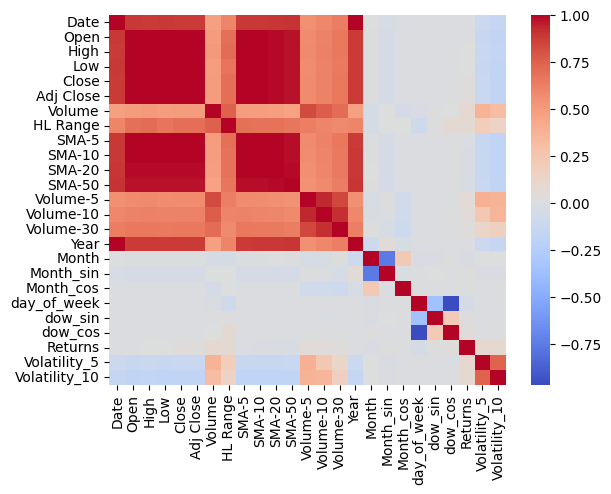

In [132]:

sns.heatmap(df.corr(), cmap="coolwarm")

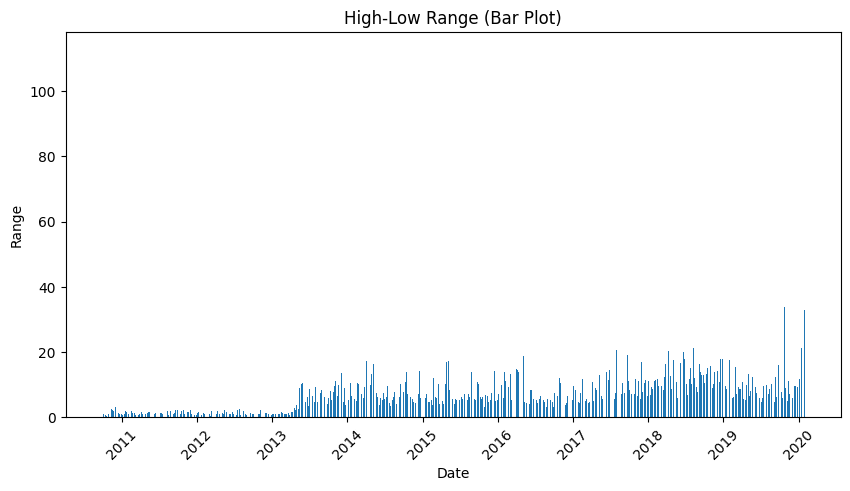

In [143]:
plt.figure(figsize=(10,5))

plt.bar(df["Date"], df["High"] - df["Low"])

plt.title("High-Low Range (Bar Plot)")
plt.xlabel("Date")
plt.ylabel("Range")
plt.xticks(rotation=45)

plt.show()